In [2]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import pandas as pd

import re
big_plt_font()

In [2]:
data_dir = '/home/electron/data/experiment_07142026'
all_files = list_filenames(data_dir)

In [27]:
data_dir = '/home/electron/data/experiment_07142026'
all_files = list_filenames(data_dir)
all_files.sort() 
all_files

['RFPowerConstSweepTipSwitched_10-15-04.h5',
 'RFPowerConstSweepTipSwitched_10-26-26.h5',
 'RFPowerConstSweepTipSwitched_10-37-16.h5',
 'RFPowerConstSweepTipSwitched_10-38-31.h5',
 'RFPowerConstSweepTipSwitched_10-39-46.h5',
 'RFPowerConstSweepTipSwitched_10-41-01.h5',
 'RFPowerConstSweepTipSwitched_10-42-16.h5',
 'RFPowerConstSweepTipSwitched_10-55-37.h5',
 'RFPowerConstSweepTipSwitched_10-56-52.h5',
 'RFPowerConstSweepTipSwitched_10-58-07.h5',
 'RFPowerConstSweepTipSwitched_10-59-23.h5',
 'RFPowerConstSweepTipSwitched_11-00-38.h5',
 'RFPowerConstSweepTipSwitched_11-01-54.h5',
 'RFPowerConstSweepTipSwitched_11-03-09.h5',
 'RFPowerConstSweepTipSwitched_11-04-24.h5',
 'RFPowerConstSweepTipSwitched_11-05-39.h5',
 'RFPowerConstSweepTipSwitched_11-06-54.h5',
 'RFPowerConstSweepTipSwitched_11-12-50.h5',
 'RFPowerConstSweepTipSwitched_11-14-06.h5',
 'RFPowerConstSweepTipSwitched_11-15-21.h5',
 'RFPowerConstSweepTipSwitched_11-16-36.h5',
 'RFPowerConstSweepTipSwitched_11-17-52.h5',
 'RFPowerC

In [3]:
file = load_latest_data() 
file['filename']

'/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_16-15-57.h5'

In [4]:
%matplotlib inline
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Helper functions (Ensure dBm_to_W, load_h5_data, and data_dir are defined) ---
# def dBm_to_W(dbm): ...
# def load_h5_data(filepath, base=None): ...
# data_dir = '/home/electron/data/experiment_07142026'

# 1. Map your "Tip on" and "Tip off" files to their respective t_load values
# (Update these lists with your actual target filenames)
tip_on_files = [
    'RFPowerSweepOnOffDifferential_15-04-07.h5',
 'RFPowerSweepOnOffDifferential_15-24-31.h5',
 'RFPowerSweepOnOffDifferential_15-52-42.h5',
 'RFPowerSweepOnOffDifferential_16-00-35.h5',
 'RFPowerSweepOnOffDifferential_16-15-57.h5',
]

tip_off_files = [
    '/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_12-20-02.h5',
]

on_map = {}
off_map = {}

print("Scanning datasets for t_load...")
# Scan Tip-On files
for f in tip_on_files:
    try:
        f_data = load_h5_data(f, base=data_dir)
        t_val = f_data.get('t_load', None)
        if t_val is not None:
            on_map[t_val] = f
    except Exception as e:
        print(f"Skipping Tip-On file {f}: {e}")

# Scan Tip-Off files
for f in tip_off_files:
    try:
        f_data = load_h5_data(f, base=data_dir)
        t_val = f_data.get('t_load', None)
        if t_val is not None:
            off_map[t_val] = f
    except Exception as e:
        print(f"Skipping Tip-Off file {f}: {e}")

# We use unique t_loads available in the "Tip on" set for our selection
unique_t_loads = sorted(list(on_map.keys()))
print(f"Scan complete. Found {len(unique_t_loads)} valid t_load configurations.")

# 2. Setup UI elements (Dropdown and Navigation Buttons)
t_load_dropdown = widgets.Dropdown(
    options=unique_t_loads,
    value=unique_t_loads[0] if unique_t_loads else None,
    description='t_load:'
)

btn_prev = widgets.Button(
    description='Prev',
    button_style='info',     # Light blue styling
    icon='arrow-left'        # Left arrow icon
)

btn_next = widgets.Button(
    description='Next',
    button_style='primary',  # Darker blue styling
    icon='arrow-right'       # Right arrow icon
)

plot_output = widgets.Output()

# 3. Plotting logic wrapped in an output handler
def draw_plot(t_load):
    with plot_output:
        clear_output(wait=True)
        
        if t_load is None:
            print("No t_load configured.")
            return

        on_file_path = on_map.get(t_load)
        # Attempt to get the corresponding background file for the same t_load,
        # or fall back to the first available background file if a direct match doesn't exist.
        off_file_path = off_map.get(t_load) or (list(off_map.values())[0] if off_map else None)

        if not on_file_path:
            print(f"No Tip-On file found for t_load: {t_load}")
            return

        # Load file data
        file = load_h5_data(on_file_path, base=data_dir)
        data = file['all_meas']
        
        # Calculate Power in nW for Tip-On
        P_nW = dBm_to_W(np.concatenate(data, axis=0)) * 1e9 
        bin_size = 0.01

        # Plotting Setup
        fig, ax = plt.subplots(figsize=(7, 4))

        # 1. Plot Tip On Histogram
        counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW) - min(P_nW)) / bin_size))
        ax.bar(
            bin_edges[:-1], 
            counts / np.sum(counts), 
            width=np.diff(bin_edges),
            label='Tip on',
            align='edge', 
            alpha=0.6,
            color='blue'
        )

        # 2. Plot Tip Off Histogram (if background file exists)
        if off_file_path:
            file2 = load_h5_data(off_file_path, base=data_dir)
            data2 = file2['all_meas']
            P_nW_background = dBm_to_W(np.concatenate(data2, axis=0)) * 1e9

            counts_bg, bin_edges_bg = np.histogram(
                P_nW_background, 
                bins=int((max(P_nW_background) - min(P_nW_background)) / bin_size)
            )
            ax.bar(
                bin_edges_bg[:-1], 
                counts_bg / np.sum(counts_bg), 
                width=np.diff(bin_edges_bg),
                label='Tip off',
                align='edge', 
                alpha=0.6,
                color='orange'
            )

        # Graph configurations
        ax.set_yscale('log')
        ax.set_title(f"Histogram of Detected Power | t_load = {t_load}")
        ax.set_xlabel('Detected Power (nW)') 
        ax.set_ylabel('Probability Density / 0.01nW bin')
        ax.grid(True)
        ax.legend()
        plt.show()

# 4. Define event behaviors for Slider/Buttons
def on_dropdown_change(change):
    draw_plot(change['new'])

def on_next_clicked(b):
    opts = t_load_dropdown.options
    if not opts: return
    idx = opts.index(t_load_dropdown.value)
    t_load_dropdown.value = opts[idx + 1] if idx < len(opts) - 1 else opts[0]

def on_prev_clicked(b):
    opts = t_load_dropdown.options
    if not opts: return
    idx = opts.index(t_load_dropdown.value)
    t_load_dropdown.value = opts[idx - 1] if idx > 0 else opts[-1]

# Link actions to the widgets
t_load_dropdown.observe(on_dropdown_change, names='value')
btn_next.on_click(on_next_clicked)
btn_prev.on_click(on_prev_clicked)

# 5. Pack layouts and display
controls = widgets.HBox([btn_prev, t_load_dropdown, btn_next])
ui = widgets.VBox([controls, plot_output])

display(ui)

# Render the first plot
if t_load_dropdown.value is not None:
    draw_plot(t_load_dropdown.value)

Scanning datasets for t_load...
Scan complete. Found 5 valid t_load configurations.


In [5]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Placeholder functions and variables (ensure these are defined in your notebook) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# data_dir = '/path/to/base/dir' 

# 1. Gather all your files and map configurations
h5_files = ['RFPowerSweepOnOffDifferential_15-04-07.h5',
 'RFPowerSweepOnOffDifferential_15-24-31.h5',
 'RFPowerSweepOnOffDifferential_15-52-42.h5',
 'RFPowerSweepOnOffDifferential_16-00-35.h5',
 'RFPowerSweepOnOffDifferential_16-15-57.h5',] # Add your actual file list/glob here
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        data_dict = load_h5_data(filepath, base=data_dir)
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))
print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")

# 2. Set up the UI Elements
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')

btn_prev = widgets.Button(description='Prev', button_style='info', icon='arrow-left')
btn_next = widgets.Button(description='Next', button_style='primary', icon='arrow-right')

plot_output = widgets.Output()

# 3. Dynamic options updater for the Power dropdown
def update_power_options(*args):
    filepath = experiment_map.get((ex_dropdown.value, u2_dropdown.value))
    if filepath:
        # Load available powers for the selected Ex and U2
        data_dict = load_h5_data(filepath, base=data_dir)
        df = convert_dict_to_dataframe(data_dict)
        power_dropdown.options = sorted(df['dBm'].unique())
    else:
        power_dropdown.options = []

# 4. Plotting logic wrapped in the output handler
def draw_plot(change=None):
    Ex = ex_dropdown.value
    U2 = u2_dropdown.value
    Power_dBm = power_dropdown.value

    with plot_output:
        clear_output(wait=True)
        if Ex is None or U2 is None or Power_dBm is None:
            print("Awaiting valid selection...")
            return
            
        filepath = experiment_map.get((Ex, U2))
        if not filepath:
            print(f"No file found for Ex: {Ex}, U2: {U2}")
            return
            
        # Load dataset and convert
        data_dict = load_h5_data(filepath, base=data_dir)
        df = convert_dict_to_dataframe(data_dict)
        
        # Find the row for the selected power
        dbm_series = df['dBm'].astype(float)
        row = df[np.isclose(dbm_series, float(Power_dBm), atol=1e-3)]
        
        if row.empty:
            print(f"Power {Power_dBm} dBm not found in this dataset.")
            return
            
        # Extract time-domain data for the specific power
        raw_data = row['data'].values[0]
        y_data = np.array(raw_data)
        
        # Extract t_data for the x-axis (falling back to a default if missing)
        # t_seq_end = data_dict.get('t_data', 1.0) 
        t_axis = np.array(row['time'].values[0])
        
        # Plotting
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(t_axis, y_data, color='blue', lw=2)
        
        ax.set_title(f"Ex: {Ex} | U2: {U2} | RF Power: {Power_dBm} dBm")
        ax.set_xlabel("Wait time (s)")
        ax.set_ylabel("Power (dBm)") # Update this unit if you apply dBm_to_W
        ax.grid(True)
        plt.show()

# 5. Define Button Behaviors (Step through the available powers)
def on_prev_clicked(b):
    opts = power_dropdown.options
    if not opts: return
    idx = opts.index(power_dropdown.value)
    # Move back one, or wrap to the end
    power_dropdown.value = opts[idx - 1] if idx > 0 else opts[-1]

def on_next_clicked(b):
    opts = power_dropdown.options
    if not opts: return
    idx = opts.index(power_dropdown.value)
    # Move forward one, or wrap to the beginning
    power_dropdown.value = opts[idx + 1] if idx < len(opts) - 1 else opts[0]

# 6. Link Observers and Clicks
ex_dropdown.observe(update_power_options, names='value')
u2_dropdown.observe(update_power_options, names='value')
power_dropdown.observe(draw_plot, names='value')

btn_prev.on_click(on_prev_clicked)
btn_next.on_click(on_next_clicked)

# Initialize the first state
update_power_options()
if power_dropdown.options:
    draw_plot()

# 7. Layout and Display
param_controls = widgets.HBox([ex_dropdown, u2_dropdown])
power_controls = widgets.HBox([btn_prev, power_dropdown, btn_next])

ui = widgets.VBox([
    param_controls,
    power_controls, 
    plot_output
])

display(ui)

Scanning datasets...
Scan complete. Found 1 valid Ex/U2 configurations.


KeyError: 'dBm'

In [74]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Your existing data setup remains here ---
# (Ensure t_axis and data are defined above this cell)
file = load_latest_data() #load_h5_data('/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_16-58-52.h5') #
data = file['all_meas'] 
t_seq_end = file['t_data']
t_axis = np.linspace(0, t_seq_end, len(data[0])) 

# 1. Setup UI elements (Slider and Navigation Buttons)
slider = widgets.IntSlider(
    value=0, 
    min=0, 
    max=len(data) - 1, 
    step=1, 
    description='Index (i):'
)

btn_prev = widgets.Button(
    description='Prev',
    button_style='info',     # Light blue styling
    icon='arrow-left'        # Left arrow icon
)

btn_next = widgets.Button(
    description='Next',
    button_style='primary',  # Darker blue styling
    icon='arrow-right'       # Right arrow icon
)

# Output container to catch the plot and refresh it cleanly
plot_output = widgets.Output()

# 2. Plotting logic wrapped in an output handler
def draw_plot(i):
    with plot_output:
        clear_output(wait=True)  # Instantly clears the old plot
        
        fig, ax = plt.subplots(figsize=(7, 4))
        # Using your exact variables and scalings
        ax.plot(t_axis * 1e3, data[i], color='blue', lw=2)
        
        ax.set_title(f"Plotting dataset i = {i}")
        ax.set_xlabel("Wait time (ms)")
        ax.set_ylabel("Power (dBm)")
        ax.grid(True)
        plt.show()

# 3. Define event behaviors
def on_slider_change(change):
    draw_plot(change['new'])

def on_next_clicked(b):
    # Advances the slider, looping back to 0 if at the end
    if slider.value < slider.max:
        slider.value += 1
    else:
        slider.value = 0

def on_prev_clicked(b):
    # Rewinds the slider, looping to the end if at 0
    if slider.value > slider.min:
        slider.value -= 1
    else:
        slider.value = slider.max

# Link actions to the widgets
slider.observe(on_slider_change, names='value')
btn_next.on_click(on_next_clicked)
btn_prev.on_click(on_prev_clicked)

# 4. Pack layouts in a clean media-player style order and display
controls = widgets.HBox([btn_prev, slider, btn_next])
ui = widgets.VBox([controls, plot_output])

display(ui)

# Render the very first plot upon cell execution
draw_plot(slider.value)

In [64]:
file['filename']

'/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_12-39-26.h5'

In [77]:
file['filename']

'/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_19-42-56.h5'

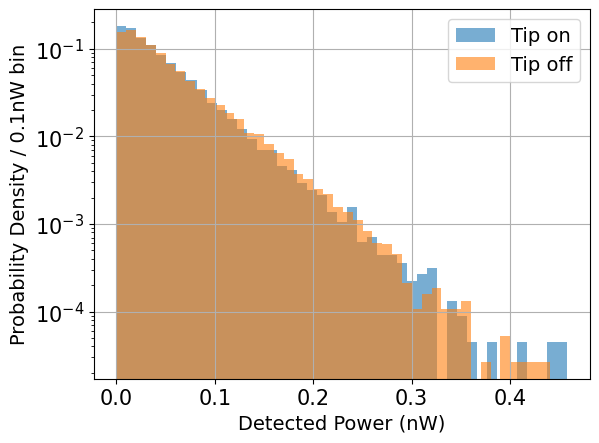

In [76]:
file = load_latest_data()#load_h5_data('/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_11-55-06.h5') #
data = file['all_meas'] 
file2 = load_h5_data('/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_12-20-02.h5') 
data2 = file2['all_meas'] 
P_nW = dBm_to_W(np.concatenate(data, axis=0))*1e9 
P_nW_background = dBm_to_W(np.concatenate(data2, axis=0))*1e9
bin_size = 0.01

counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW)-min(P_nW))/bin_size))#, alpha=0.7, label='Tip on')
plt.bar(
    bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
    counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
    width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
    label='Tip on',
    align='edge',            # Align the bars to start at the left bin edge
    alpha=0.6                # Transparency
)

counts, bin_edges = np.histogram(P_nW_background, bins=int((max(P_nW_background)-min(P_nW_background))/bin_size))#, alpha=0.7, label='Tip off')
# plt.xscale('log') 
plt.bar(
    bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
    counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
    width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
    label='Tip off',
    align='edge',            # Align the bars to start at the left bin edge
    alpha=0.6                # Transparency
)



plt.yscale('log')
plt.xlabel('Detected Power (nW)') 
plt.ylabel('Probability Density / 0.1nW bin')
plt.grid()
plt.legend()
plt.show()

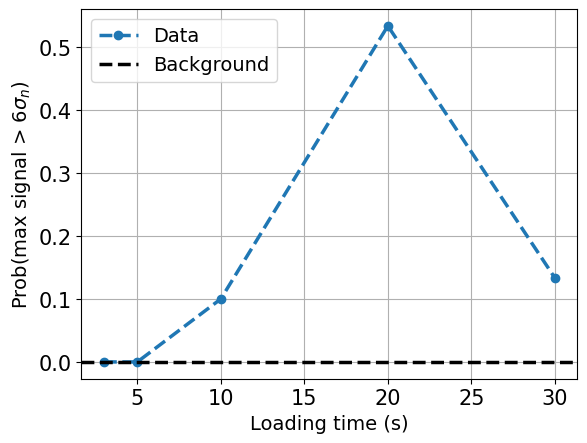

In [75]:
tip_on_files = [
    'RFPowerSweepOnOffDifferential_15-04-07.h5',
 'RFPowerSweepOnOffDifferential_15-24-31.h5',
 'RFPowerSweepOnOffDifferential_15-52-42.h5',
 'RFPowerSweepOnOffDifferential_16-00-35.h5',
 'RFPowerSweepOnOffDifferential_16-15-57.h5',
]

tip_off_files = [
    '/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_12-20-02.h5',
]
file2 = load_h5_data(tip_off_files[0]) 
data2 = file2['all_meas'] 
P_nW_background = dBm_to_W(np.max(data2, axis=1))*1e9
Pth = np.mean(P_nW_background) + 8*np.std(P_nW_background)
P_background = len(np.where(P_nW_background>Pth)[0]) / len(P_nW_background)

all_t_load = [] 
all_P_signal = []
for filename in tip_on_files: 
    file = load_h5_data(filename, base=data_dir)
    data = file['all_meas'] 
    P_nW = dBm_to_W(np.max(data, axis=1))*1e9
    P_signal = len(np.where(P_nW>Pth)[0]) / len(P_nW)
    all_t_load.append(file['t_load']) 
    all_P_signal.append(P_signal) 
idx = np.argsort(all_t_load)
plot(np.array(all_t_load)[idx], np.array(all_P_signal)[idx], '.--', xlabel='Loading time (s)', ylabel=r'Prob(max signal > 6$\sigma_n$)', label='Data')
plt.axhline(P_background, linestyle='--', c='k', label='Background') 
# plt.yscale('log')
plt.legend() 
plt.show()

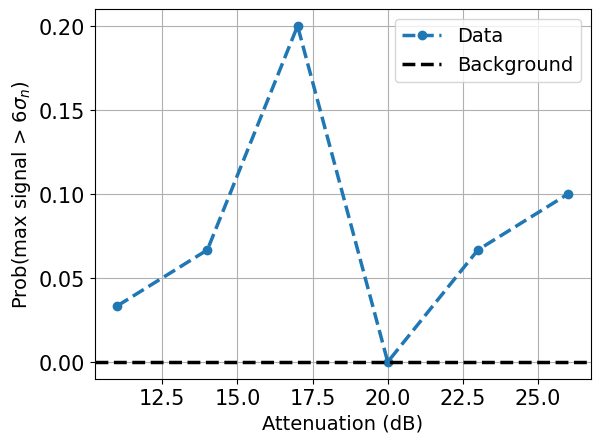

In [79]:
tip_on_files = [
    'RFPowerSweepOnOffDifferential_18-03-32.h5',
    'RFPowerSweepOnOffDifferential_18-27-28.h5', 
    'RFPowerSweepOnOffDifferential_18-49-01.h5',
    'RFPowerSweepOnOffDifferential_19-06-31.h5', 
    'RFPowerSweepOnOffDifferential_19-25-22.h5',
    'RFPowerSweepOnOffDifferential_19-42-56.h5'
]

tip_off_files = [
    '/home/electron/data/experiment_07142026/RFPowerSweepOnOffDifferential_12-20-02.h5',
]
file2 = load_h5_data(tip_off_files[0]) 
data2 = file2['all_meas'] 
P_nW_background = dBm_to_W(np.max(data2, axis=1))*1e9
Pth = np.mean(P_nW_background) + 8*np.std(P_nW_background)
P_background = len(np.where(P_nW_background>Pth)[0]) / len(P_nW_background)

all_atten = [17, 11, 23, 26, 14, 20] 
all_P_signal = []
for filename in tip_on_files: 
    file = load_h5_data(filename, base=data_dir)
    data = file['all_meas'] 
    P_nW = dBm_to_W(np.max(data, axis=1))*1e9
    P_signal = len(np.where(P_nW>Pth)[0]) / len(P_nW)
    all_t_load.append(file['t_load']) 
    all_P_signal.append(P_signal) 
idx = np.argsort(all_atten)
plot(np.array(all_atten)[idx], np.array(all_P_signal)[idx], '.--', xlabel='Attenuation (dB)', ylabel=r'Prob(max signal > 6$\sigma_n$)', label='Data')
plt.axhline(P_background, linestyle='--', c='k', label='Background') 
# plt.yscale('log')
plt.legend() 
plt.show()

In [43]:
len(np.where(P_nW>Pth))

1

In [74]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
# Modify this path/pattern to match where your h5 files are stored
h5_files = ['RFPowerConstSweepTipSwitched_13-12-06.h5',]
            

# 2. Pre-scan files to map (Ex, U2) -> File Path
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        # Load metadata
        data_dict = load_h5_data(filepath, base=data_dir)
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            # Using string keys or tuple keys for the mapping
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

# Extract unique sorted values for the dropdown menus
unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")

# 3. Define the plotting function that the widget will trigger
# 3. Define the plotting function that the widget will trigger
def plot_experiment_data(Ex, U2, Power_dBm):
    # Guard against initialization / update frames where values are momentarily None
    if Ex is None or U2 is None or Power_dBm is None:
        return
        
    filepath = experiment_map.get((Ex, U2))
    
    if not filepath:
        print(f"No file found for Ex: {Ex}, U2: {U2}")
        return
        
    # Load and process the specific file
    data_dict = load_h5_data(filepath, base=data_dir)
    df = convert_dict_to_dataframe(data_dict)
    
    # Find the row corresponding to the selected power
    # Converting df['dBm'] to a float series explicitly just in case it's loaded as object type
    dbm_series = df['dBm'].astype(float)
    row = df[np.isclose(dbm_series, float(Power_dBm), atol=1e-3)]
    
    if row.empty:
        print(f"Power {Power_dBm} dBm not found in this dataset.")
        return
        
    # Extract the data array for this specific power level
    raw_data = row['data'].values[0]
    data = dBm_to_W(np.array(raw_data)) * 1e9
    
    # Calculate your metric (fraction of data > 10x mean)
    mean_val = np.mean(data)
    if mean_val > 0:
        max_data = len(data[data > 10 * mean_val]) / len(data)
    else:
        max_data = 0
        
    # Generate the plot
    plt.figure(figsize=(8, 5))
    plt.hist(data, density=True, bins=50, alpha=0.75, color='b', edgecolor='black')
    plt.title(f'Ex: {Ex} | U2: {U2} | Power: {Power_dBm:.2f} dBm\nMetric ( >10x Mean Ratio): {max_data:.4f}')
    # plt.xlim(-0.1,)
    plt.xlabel('Power (nW)')
    plt.ylabel('Density (Log Scale)')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.show()

# 4. Create Dynamic Interactive Dashboard
# We link the power dropdown options dynamically based on which Ex and U2 are picked
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')

def update_power_options(*args):
    filepath = experiment_map.get((ex_dropdown.value, u2_dropdown.value))
    if filepath:
        # Quickly load dataframe to extract available power levels for this specific file
        data_dict = load_h5_data(filepath, base=data_dir)
        df = convert_dict_to_dataframe(data_dict)
        power_dropdown.options = sorted(df['dBm'].unique())
    else:
        power_dropdown.options = []

# Trigger option updates whenever Ex or U2 selections change
ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

# Initialize the power dropdown options for the default starting values
update_power_options()

# Render the interactive panel
interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

# Display widgets neatly grouped together
widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 1 valid Ex/U2 configurations.


In [147]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
# Modify this path/pattern to match where your h5 files are stored
h5_files = ['RFPowerConstSweepTipSwitched_18-46-18.h5',
 'RFPowerConstSweepTipSwitched_18-47-33.h5',
              'RFPowerConstSweepTipSwitched_18-48-47.h5','RFPowerConstSweepTipSwitched_18-50-02.h5'
 ]
            

# 2. Pre-scan files to map (Ex, U2) -> File Path
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        # Load metadata
        data_dict = load_h5_data(filepath, base='/home/electron/data/experiment_07092026')
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            # Using string keys or tuple keys for the mapping
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

# Extract unique sorted values for the dropdown menus
unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")



# 4. Create Dynamic Interactive Dashboard
# We link the power dropdown options dynamically based on which Ex and U2 are picked
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')


# Trigger option updates whenever Ex or U2 selections change
ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

# Initialize the power dropdown options for the default starting values
update_power_options()

# Render the interactive panel
interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

# Display widgets neatly grouped together
widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 4 valid Ex/U2 configurations.


In [145]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
# Modify this path/pattern to match where your h5 files are stored
h5_files = ['RFPowerConstSweepTipSwitched_18-52-14.h5',
 'RFPowerConstSweepTipSwitched_18-53-29.h5',
              'RFPowerConstSweepTipSwitched_18-54-43.h5','RFPowerConstSweepTipSwitched_18-55-57.h5'
 ]
            

# 2. Pre-scan files to map (Ex, U2) -> File Path
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        # Load metadata
        data_dict = load_h5_data(filepath, base='/home/electron/data/experiment_07092026')
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            # Using string keys or tuple keys for the mapping
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

# Extract unique sorted values for the dropdown menus
unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")



# 4. Create Dynamic Interactive Dashboard
# We link the power dropdown options dynamically based on which Ex and U2 are picked
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')


# Trigger option updates whenever Ex or U2 selections change
ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

# Initialize the power dropdown options for the default starting values
update_power_options()

# Render the interactive panel
interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

# Display widgets neatly grouped together
widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 4 valid Ex/U2 configurations.


In [144]:
%matplotlib inline
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# --- Placeholder functions (keep your actual implementations here) ---
# def load_h5_data(filepath, base): ...
# def convert_dict_to_dataframe(data_dict): ...
# def dBm_to_W(dbm): ...

# 1. Gather all your files
# Modify this path/pattern to match where your h5 files are stored
h5_files = ['RFPowerConstSweepTipSwitched_19-00-15.h5', 
            'RFPowerConstSweepTipSwitched_19-01-29.h5','RFPowerConstSweepTipSwitched_19-02-43.h5','RFPowerConstSweepTipSwitched_19-03-58.h5'
 ]
            

# 2. Pre-scan files to map (Ex, U2) -> File Path
experiment_map = {}

print("Scanning datasets...")
for filepath in h5_files:
    try:
        # Load metadata
        data_dict = load_h5_data(filepath, base='/home/electron/data/experiment_07092026')
        ex_val = data_dict.get('Ex', None)
        u2_val = data_dict.get('U2', None)
        
        if ex_val is not None and u2_val is not None:
            # Using string keys or tuple keys for the mapping
            experiment_map[(ex_val, u2_val)] = filepath
    except Exception as e:
        print(f"Skipping {filepath} due to error: {e}")

# Extract unique sorted values for the dropdown menus
unique_Ex = sorted(list(set(k[0] for k in experiment_map.keys())))
unique_U2 = sorted(list(set(k[1] for k in experiment_map.keys())))

print(f"Scan complete. Found {len(experiment_map)} valid Ex/U2 configurations.")



# 4. Create Dynamic Interactive Dashboard
# We link the power dropdown options dynamically based on which Ex and U2 are picked
ex_dropdown = widgets.Dropdown(options=unique_Ex, description='Ex:')
u2_dropdown = widgets.Dropdown(options=unique_U2, description='U2:')
power_dropdown = widgets.Dropdown(description='Power (dBm):')


# Trigger option updates whenever Ex or U2 selections change
ex_dropdown.observe(update_power_options, 'value')
u2_dropdown.observe(update_power_options, 'value')

# Initialize the power dropdown options for the default starting values
update_power_options()

# Render the interactive panel
interactive_plot = widgets.interactive_output(
    plot_experiment_data, 
    {'Ex': ex_dropdown, 'U2': u2_dropdown, 'Power_dBm': power_dropdown}
)

# Display widgets neatly grouped together
widgets.VBox([
    widgets.HBox([ex_dropdown, u2_dropdown, power_dropdown]),
    interactive_plot
])

Scanning datasets...
Scan complete. Found 4 valid Ex/U2 configurations.


In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
from edes.utils.utils import U2_to_MHz
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
from edes.utils.file_handling import list_filepaths, list_files_in_time_range
from edes.experiments.analysis.lock_in_detection import plot_individual_PvT, plot_hist, compare_hist_U2_Ex_continuous_loading, \
                                                        plot_Prob_vs_var, compare_PvT_U2_Ex_continuous_loading
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import datetime
import pandas as pd

import re
big_plt_font()

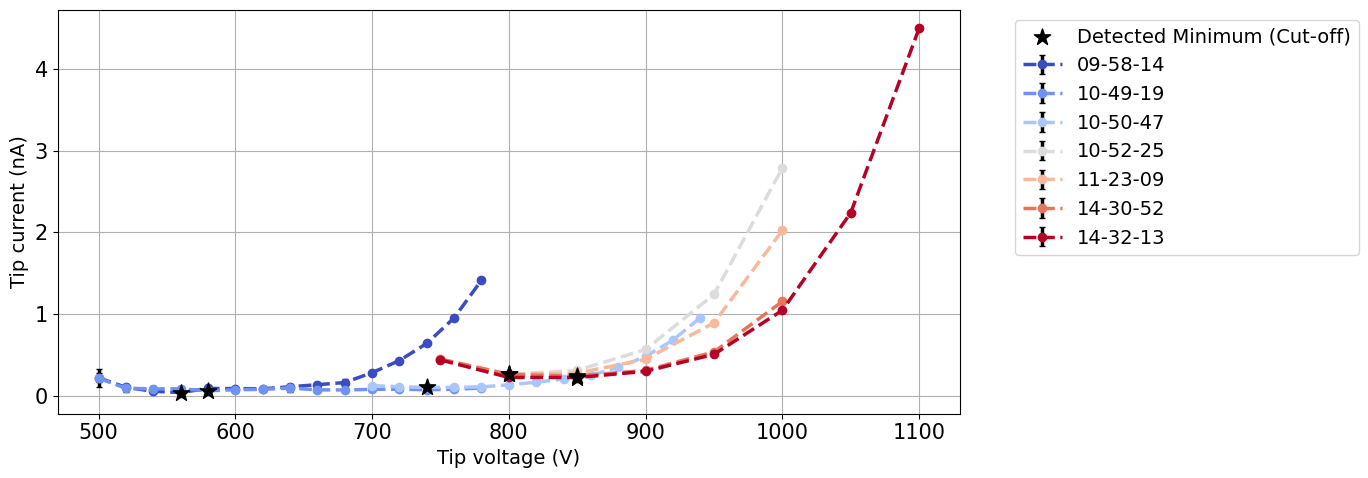

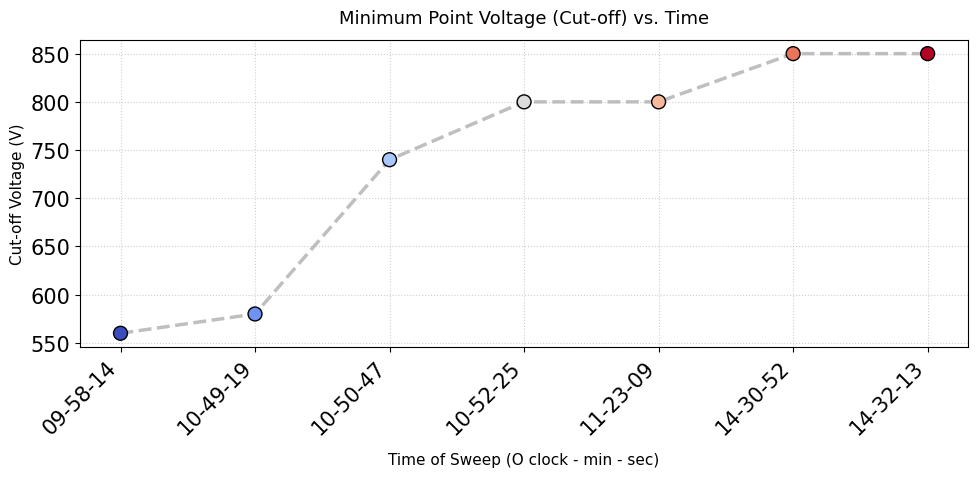

In [49]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the list of files and sort them in ascending chronological order
all_files = list_files_in_time_range(data_dir, name='TipVoltageSweepDifferential', start_time='09:58:00')
all_files = sorted(all_files)  
num_files = len(all_files)

# Generate a distinct color palette using 'coolwarm'
colors = plt.cm.coolwarm(np.linspace(0, 1, num_files))

# Initialize lists to track data for the single summary graph
sweep_indices = []
sweep_labels = []
cutoff_voltage_list = []

# ==========================================
# FIGURE 1: Raw Voltage Sweeps (Stretched)
# ==========================================
plt.figure(figsize=(14, 5)) 

for i, file_path in enumerate(all_files):
    file = load_h5_data(file_path)
    
    v_data = file['all_V']
    mean_i_nA = np.mean(file['all_I'], axis=1) * 1e9
    std_i_nA = np.std(file['all_I'], axis=1) * 1e9
    
    # --- EXTRACT TIMESTAMP FOR LEGEND ---
    filename = os.path.basename(file_path)
    time_match = re.search(r'\d{2}-\d{2}-\d{2}', filename)
    
    if time_match:
        sweep_label = time_match.group(0) # e.g. "09-58-14"
    else:
        sweep_label = filename.replace('.h5', '')
    
    # Plot the full raw sweep line with black error bars
    plot_errbar(
        v_data, 
        mean_i_nA, 
        yerr=std_i_nA, 
        fmt='.--', 
        xlabel='Tip voltage (V)', 
        ylabel='Tip current (nA)', 
        color=colors[i],       
        ecolor='black',        
        label=sweep_label      
    )
    
    # --- CUT-OFF AS THE MINIMUM POINT OF THE DATA ---
    min_idx = np.argmin(mean_i_nA)
    cutoff_v = v_data[min_idx]
    cutoff_i = mean_i_nA[min_idx]
                
    # Store the detected values for the summary plot
    sweep_indices.append(i + 1)
    sweep_labels.append(sweep_label)
    cutoff_voltage_list.append(cutoff_v)
    
    # Mark the minimum point directly on the raw graph with a black star
    plt.scatter(cutoff_v, cutoff_i, color='black', marker='*', s=150, zorder=5, 
                label='Detected Minimum (Cut-off)' if i == 0 else "")

# Format Figure 1
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()


# ==========================================
# FIGURE 2: Single Summary Plot (Cut-off vs Time)
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 5))  # Adjusted size for a single, focused graph

# Plot trend line to guide the eye
ax2.plot(sweep_indices, cutoff_voltage_list, color='gray', linestyle='--', alpha=0.5, zorder=1)

# Scatter plot using 'coolwarm' colormap to keep visual continuity with Figure 1
ax2.scatter(
    sweep_indices, 
    cutoff_voltage_list, 
    c=sweep_indices, 
    cmap='coolwarm', 
    edgecolor='black', 
    s=100, 
    zorder=2
)

# Format the summary graph
ax2.set_title('Minimum Point Voltage (Cut-off) vs. Time', fontsize=13, pad=12)
ax2.set_xlabel('Time of Sweep (O clock - min - sec)', fontsize=11, labelpad=10)
ax2.set_ylabel('Cut-off Voltage (V)', fontsize=11)

# Map the exact timestamps to the x-axis ticks
ax2.set_xticks(sweep_indices)
ax2.set_xticklabels(sweep_labels, rotation=45, ha='right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()